# Customer Analytics — Descriptive Analysis & Segment Profiling
**Author:** Manzoor Syiemlieh  
**Date:** 2025  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  

## Objective
Analyse customer purchase behaviour across segments identified in the Segmentation notebook. Profile each segment by purchase incidence, brand preference, quantity and revenue contribution to generate actionable marketing and pricing insights.

## Dependencies
This notebook loads the trained Scaler, PCA and KMeans models saved from 01_Segmentation.ipynb. Run that notebook first to generate the required pickle files.

## 1. Importing Libraries

In [1]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Loading Data
Loading the purchase dataset containing transaction level data for 2000 customers across multiple shopping occasions including brand choices, prices, promotions and purchase quantities.

In [2]:
raw_data = pd.read_csv("data/purchase_data.csv")
df_purchase = raw_data.copy()

In [3]:
df_purchase.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,Price_4,Price_5,Promotion_1,Promotion_2,Promotion_3,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,2.09,2.66,0,1,0,0,0,0,0,47,1,110866,1,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0


## 3. Loading Trained Segmentation Models
Loading the pre-trained Scaler, PCA and KMeans models from the Segmentation notebook to assign each customer in the purchase dataset to their corresponding segment.

This ensures segment assignments are consistent with the clustering performed in the previous notebook.

In [4]:
scaler = pickle.load(open('models/scaler.pickle', 'rb'))
pca = pickle.load(open('models/pca.pickle', 'rb'))
kmeans_pca = pickle.load(open('models/kmeans_pca.pickle', 'rb'))

In [5]:
df_purchase.columns.values

array(['ID', 'Day', 'Incidence', 'Brand', 'Quantity', 'Last_Inc_Brand',
       'Last_Inc_Quantity', 'Price_1', 'Price_2', 'Price_3', 'Price_4',
       'Price_5', 'Promotion_1', 'Promotion_2', 'Promotion_3',
       'Promotion_4', 'Promotion_5', 'Sex', 'Marital status', 'Age',
       'Education', 'Income', 'Occupation', 'Settlement size'],
      dtype=object)

## 5. Assigning Segments to Purchase Data
Applying the trained Scaler, PCA and KMeans models to transform customer demographic features and assign each customer to theircorresponding segment from the Segmentation notebook.

In [6]:
features = df_purchase[['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']]

purchase_std = scaler.transform(features)
purchase_pca = pca.transform(purchase_std)
purchase_pca_kmeans = kmeans_pca.predict(purchase_pca)

df_purchase_predictors = df_purchase.copy()
df_purchase_predictors['Segments'] = purchase_pca_kmeans

df_purchase_predictors

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,Price_4,Price_5,Promotion_1,Promotion_2,Promotion_3,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segments
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,2.09,2.66,0,1,0,0,0,0,0,47,1,110866,1,0,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58688,200000500,703,0,0,0,2,1,1.41,1.85,2.01,2.24,2.79,0,0,1,0,0,0,0,42,1,120946,1,0,0
58689,200000500,710,0,0,0,0,0,1.36,1.84,2.09,2.24,2.77,0,0,0,0,0,0,0,42,1,120946,1,0,0
58690,200000500,717,0,0,0,0,0,1.50,1.80,2.14,2.24,2.75,0,0,0,0,0,0,0,42,1,120946,1,0,0
58691,200000500,722,1,2,3,0,0,1.51,1.82,2.09,2.24,2.80,0,0,0,0,0,0,0,42,1,120946,1,0,0


## 6. Segment Proportions
Analysing the distribution of customers across segments in the purchase dataset to confirm alignment with the original segmentation proportions.

In [7]:
temp1 = df_purchase_predictors[['ID', 'Incidence']].groupby('ID', as_index=False).count()
temp1 = temp1.set_index('ID')
temp1 = temp1.rename(columns={'Incidence': 'N_Visits'})

In [8]:
temp2 = df_purchase_predictors[['ID', 'Incidence']].groupby('ID', as_index=False).sum()
temp2 = temp2.set_index('ID')
temp2 = temp2.rename(columns={'Incidence': 'N_Purchases'})
temp3 = temp1.join(temp2)

In [9]:
temp3['Avg_N_Purchases'] = temp3['N_Purchases'] / temp3['N_Visits']

In [10]:
temp4 = df_purchase_predictors[['ID', 'Segments']].groupby('ID', as_index=False).first()
temp4 = temp4.set_index('ID')
df_purchase_descr = temp3.join(temp4)
df_purchase_descr

,N_Visits,N_Purchases,Avg_N_Purchases,Segments
ID,,,,
200000001,101,9,0.089109,0
200000002,87,11,0.126437,3
200000003,97,10,0.103093,0
200000004,85,11,0.129412,1
200000005,111,13,0.117117,0
...,...,...,...,...
200000496,120,20,0.166667,1
200000497,120,43,0.358333,1
200000498,131,39,0.297710,2


In [11]:
segm_prop = df_purchase_descr[['N_Purchases', 'Segments']].groupby('Segments').count() / df_purchase_descr.shape[0]
segm_prop = segm_prop.rename(columns={'N_Purchases': 'Segment_Proportions'})
segm_prop

,Segment_Proportions
Segments,
0,0.290
1,0.362
2,0.152
3,0.196


Text(0.5, 1.0, 'Segment Proportions')

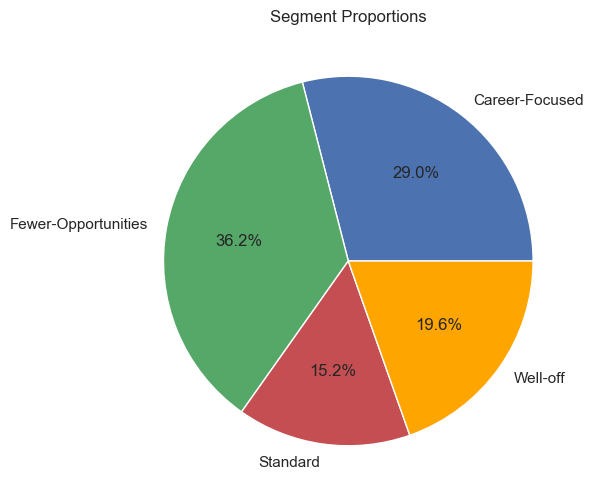

In [12]:
plt.figure(figsize=(9,6))
plt.pie(segm_prop['Segment_Proportions'],
       autopct='%1.1f%%',
        labels=['Career-Focused', 'Fewer-Opportunities', 'Standard', 'Well-off'],
       colors=('b', 'g', 'r', 'orange'))
plt.title('Segment Proportions')

## 7. Purchase Incidence Analysis
Examining the proportion of shopping occasions where each segment actually made a purchase (Incidence = 1).

This reveals which segments are most active buyers versus browsers — critical for targeting promotional spend effectively.

In [13]:
segm_mean = df_purchase_descr.groupby('Segments').mean()
segm_mean

,N_Visits,N_Purchases,Avg_N_Purchases
Segments,,,
0,120.489655,34.965517,0.258081
1,114.303867,22.823204,0.201760
2,118.828947,27.171053,0.228956
3,117.367347,34.408163,0.282601


In [14]:
segm_std = df_purchase_descr.groupby('Segments').std()
segm_std

,N_Visits,N_Purchases,Avg_N_Purchases
Segments,,,
0,39.398448,47.564198,0.181261
1,17.762052,13.851663,0.120124
2,19.834239,19.495222,0.146761
3,20.840775,25.997160,0.172682


Text(0.5, 1.0, 'Number of Visits by Segments')

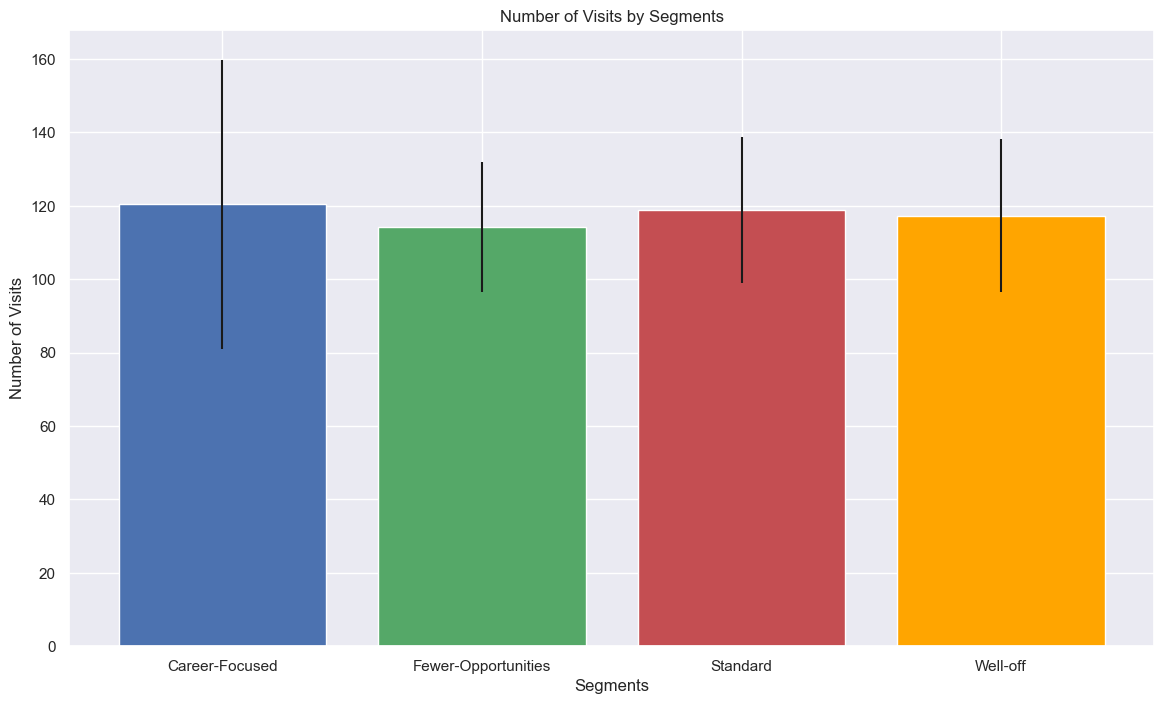

In [15]:
plt.figure(figsize=(14,8))
plt.bar(x = [0, 1, 2, 3],
       tick_label = ('Career-Focused', 'Fewer-Opportunities', 'Standard', 'Well-off'),
       height = segm_mean['N_Visits'],
       yerr = segm_std['N_Visits'],
       color = ('b', 'g', 'r', 'orange'))
plt.xlabel('Segments')
plt.ylabel('Number of Visits')
plt.title('Number of Visits by Segments')

Text(0.5, 1.0, 'Number of Purchases by Segments')

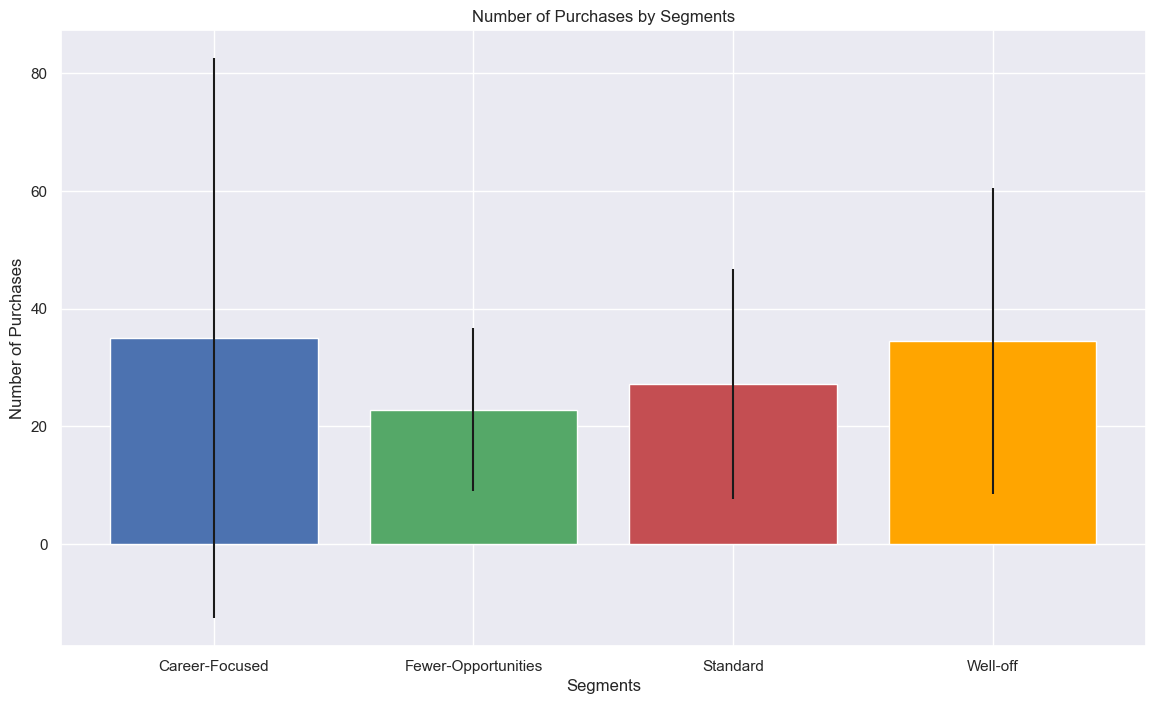

In [16]:
plt.figure(figsize=(14,8))
plt.bar(x = [0, 1, 2, 3],
       tick_label = ('Career-Focused', 'Fewer-Opportunities', 'Standard', 'Well-off'),
       height = segm_mean['N_Purchases'],
       yerr = segm_std['N_Purchases'],
       color = ('b', 'g', 'r', 'orange'))
plt.xlabel('Segments')
plt.ylabel('Number of Purchases')
plt.title('Number of Purchases by Segments')

Text(0.5, 1.0, 'Number of Average Purchases by Segments')

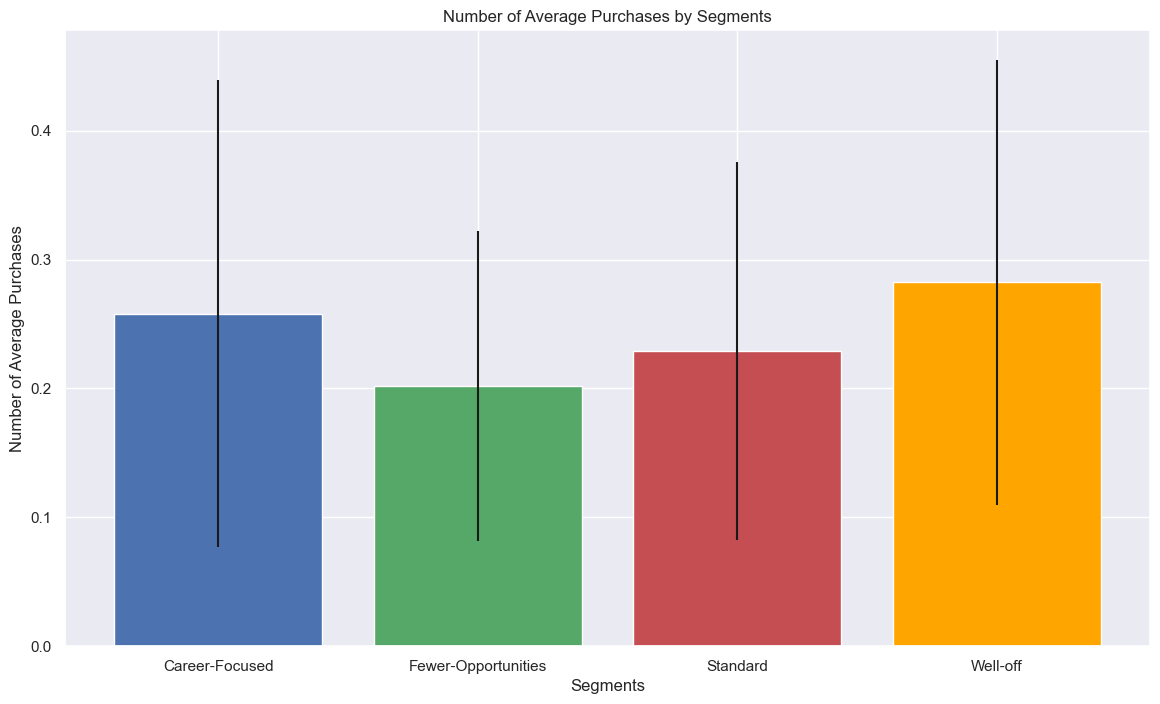

In [17]:
plt.figure(figsize=(14,8))
plt.bar(x = [0, 1, 2, 3],
       tick_label = ('Career-Focused', 'Fewer-Opportunities', 'Standard', 'Well-off'),
       height = segm_mean['Avg_N_Purchases'],
       yerr = segm_std['Avg_N_Purchases'],
       color = ('b', 'g', 'r', 'orange'))
plt.xlabel('Segments')
plt.ylabel('Number of Average Purchases')
plt.title('Number of Average Purchases by Segments')

## 8. Brand Choice Analysis by Segment
Analysing which brands each customer segment prefers when they make a purchase decision.

Understanding brand loyalty and switching behaviour by segment enables targeted brand positioning and competitive pricing strategies.

In [18]:
df_purchase_incidence = df_purchase_predictors[df_purchase_predictors['Incidence'] == 1]
df_purchase_incidence.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,Price_4,Price_5,Promotion_1,Promotion_2,Promotion_3,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segments
6,200000001,28,1,2,2,0,0,1.50,1.90,1.99,2.09,2.67,0,0,0,0,0,0,0,47,1,110866,1,0,0
11,200000001,58,1,5,1,0,0,1.39,1.90,1.91,2.12,2.62,1,0,0,0,1,0,0,47,1,110866,1,0,0
19,200000001,110,1,1,2,0,0,1.47,1.90,1.99,1.97,2.67,0,0,0,1,0,0,0,47,1,110866,1,0,0
24,200000001,142,1,4,1,0,0,1.21,1.35,1.99,2.16,2.68,1,1,0,0,0,0,0,47,1,110866,1,0,0
29,200000001,183,1,2,3,0,0,1.46,1.88,1.97,1.89,2.37,1,0,0,1,1,0,0,47,1,110866,1,0,0


In [19]:
brand_dummies = pd.get_dummies(df_purchase_incidence['Brand'], prefix='Brand', prefix_sep='_', dtype=int)
brand_dummies['Segments'], brand_dummies['ID'] = df_purchase_incidence['Segments'], df_purchase_incidence['ID']
brand_dummies

,Brand_1,Brand_2,Brand_3,Brand_4,Brand_5,Segments,ID
6,0,1,0,0,0,0,200000001
11,0,0,0,0,1,0,200000001
19,1,0,0,0,0,0,200000001
24,0,0,0,1,0,0,200000001
29,0,1,0,0,0,0,200000001
...,...,...,...,...,...,...,...
58621,0,1,0,0,0,0,200000500
58648,1,0,0,0,0,0,200000500
58674,0,1,0,0,0,0,200000500
58687,0,1,0,0,0,0,200000500


In [20]:
temp = brand_dummies.groupby('ID').mean()
mean_brand_choice = temp.groupby('Segments').mean()
mean_brand_choice

,Brand_1,Brand_2,Brand_3,Brand_4,Brand_5
Segments,,,,,
0.0,0.079019,0.329006,0.029233,0.093493,0.469248
1.0,0.167302,0.597683,0.061925,0.069068,0.104022
2.0,0.232219,0.373984,0.119907,0.077677,0.196212
3.0,0.047030,0.131953,0.029682,0.594854,0.196479


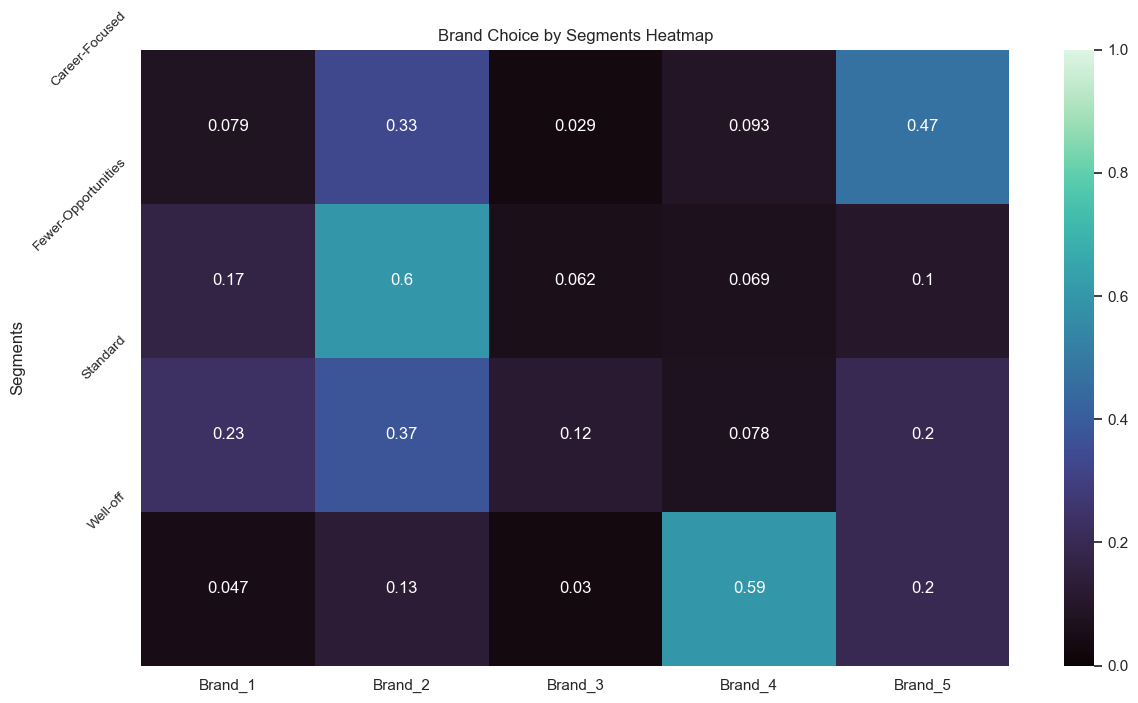

In [21]:
plt.figure(figsize=(14,8))
sns.heatmap(mean_brand_choice, annot=True, vmin=-0, vmax=1, cmap='mako')
plt.yticks([0, 1, 2, 3], ['Career-Focused', 'Fewer-Opportunities', 'Standard', 'Well-off'], rotation=45, fontsize=10)
plt.title('Brand Choice by Segments Heatmap')
plt.show()

## 9. Revenue and Quantity Analysis by Segment
Calculating total revenue contribution and average purchase quantity per segment to identify the highest value customer groups.

This analysis directly informs resource allocation — which segments deserve premium retention efforts versus acquisition focus.

In [22]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 1]
temp.loc[:, 'Revenue_Brand_1'] = temp['Price_1'] * temp['Quantity']
segm_brand_revenue = pd.DataFrame()
segm_brand_revenue[['Segments', 'Revenue_Brand_1']] = temp[['Segments', 'Revenue_Brand_1']].groupby('Segments', as_index=False).sum()

In [23]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 2]
temp.loc[:, 'Revenue_Brand_2'] = temp['Price_2'] * temp['Quantity']
segm_brand_revenue[['Segments', 'Revenue_Brand_2']] = temp[['Segments', 'Revenue_Brand_2']].groupby('Segments', as_index=False).sum()

In [24]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 3]
temp.loc[:, 'Revenue_Brand_3'] = temp['Price_3'] * temp['Quantity']
segm_brand_revenue[['Segments', 'Revenue_Brand_3']] = temp[['Segments', 'Revenue_Brand_3']].groupby('Segments', as_index=False).sum()

In [25]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 4]
temp.loc[:, 'Revenue_Brand_4'] = temp['Price_4'] * temp['Quantity']
segm_brand_revenue[['Segments', 'Revenue_Brand_4']] = temp[['Segments', 'Revenue_Brand_4']].groupby('Segments', as_index=False).sum()

In [26]:
temp = df_purchase_predictors[df_purchase_predictors['Brand'] == 5]
temp.loc[:, 'Revenue_Brand_5'] = temp['Price_5'] * temp['Quantity']
segm_brand_revenue[['Segments', 'Revenue_Brand_5']] = temp[['Segments', 'Revenue_Brand_5']].groupby('Segments', as_index=False).sum()

In [27]:
segm_brand_revenue['Total_Revenue'] = (segm_brand_revenue['Revenue_Brand_1'] +
                                       segm_brand_revenue['Revenue_Brand_2'] +
                                       segm_brand_revenue['Revenue_Brand_3'] +
                                       segm_brand_revenue['Revenue_Brand_4'] +
                                       segm_brand_revenue['Revenue_Brand_5'] )

In [28]:
segm_brand_revenue['Segment_Proportions'] = segm_prop['Segment_Proportions']
segm_brand_revenue['Segments'] = segm_brand_revenue['Segments'].map({0:'Career-Focused',
                                                                  1:'Fewer-Opportunities',
                                                                  2:'Standard',
                                                                  3:'Well-Off'})
segm_brand_revenue = segm_brand_revenue.set_index('Segments')
segm_brand_revenue

,Revenue_Brand_1,Revenue_Brand_2,Revenue_Brand_3,Revenue_Brand_4,Revenue_Brand_5,Total_Revenue,Segment_Proportions
Segments,,,,,,,
Career-Focused,912.12,5222.99,603.79,2268.95,17838.72,26846.57,0.290
Fewer-Opportunities,2807.51,11742.86,2388.88,1910.89,2638.52,21488.66,0.362
Standard,1869.77,3382.47,2303.31,1165.16,3638.75,12359.46,0.152
Well-Off,716.25,1419.99,725.54,13695.10,5505.01,22061.89,0.196


## 10. Summary and Key Findings

### What We Did
- Loaded and explored purchase transaction data across 2000 customers
- Applied pre-trained segmentation models to assign customers to segments
- Analysed purchase incidence, brand preference, quantity and revenue 
  by segment

### Key Findings
- Segments show meaningfully different purchase incidence rates — 
  revealing distinct buyer versus browser behaviour patterns
- Brand preferences vary significantly across segments — 
  enabling targeted brand positioning strategies
- Revenue contribution is concentrated in specific high-value segments — 
  informing where retention and upselling investments deliver most value

### Next Steps
Segment-level insights from this analysis are used in the Modelling 
notebook to build price elasticity and purchase probability models 
that quantify customer price sensitivity at segment level.